In [250]:
import numpy as np
import pandas as pd

In [251]:
# data= pd.read_csv("data/diabetes.csv")
df= pd.read_csv("C:\Diabetes_ml\ML_pred_new\data\diabetes.csv")
df.head

<>:2: SyntaxWarning: invalid escape sequence '\D'
<>:2: SyntaxWarning: invalid escape sequence '\D'
C:\Users\naman\AppData\Local\Temp\ipykernel_17012\1222998790.py:2: SyntaxWarning: invalid escape sequence '\D'
  df= pd.read_csv("C:\Diabetes_ml\ML_pred_new\data\diabetes.csv")


<bound method NDFrame.head of      Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin   BMI  \
0              6      148             72             35        0  33.6   
1              1       85             66             29        0  26.6   
2              8      183             64              0        0  23.3   
3              1       89             66             23       94  28.1   
4              0      137             40             35      168  43.1   
..           ...      ...            ...            ...      ...   ...   
763           10      101             76             48      180  32.9   
764            2      122             70             27        0  36.8   
765            5      121             72             23      112  26.2   
766            1      126             60              0        0  30.1   
767            1       93             70             31        0  30.4   

     DiabetesPedigreeFunction  Age  Outcome  
0                       0.627   50 

In [252]:
print(df.shape)
print(df.info())


(768, 9)
<class 'pandas.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB
None


Column Pregencies is only perfect when all the people are women, and there are no men

Dataset could have also included another column of 'gender' to be more specific

In [253]:
print(df.describe())

       Pregnancies     Glucose  BloodPressure  SkinThickness     Insulin  \
count   768.000000  768.000000     768.000000     768.000000  768.000000   
mean      3.845052  120.894531      69.105469      20.536458   79.799479   
std       3.369578   31.972618      19.355807      15.952218  115.244002   
min       0.000000    0.000000       0.000000       0.000000    0.000000   
25%       1.000000   99.000000      62.000000       0.000000    0.000000   
50%       3.000000  117.000000      72.000000      23.000000   30.500000   
75%       6.000000  140.250000      80.000000      32.000000  127.250000   
max      17.000000  199.000000     122.000000      99.000000  846.000000   

              BMI  DiabetesPedigreeFunction         Age     Outcome  
count  768.000000                768.000000  768.000000  768.000000  
mean    31.992578                  0.471876   33.240885    0.348958  
std      7.884160                  0.331329   11.760232    0.476951  
min      0.000000                  

In [254]:
# finding no: of zeroes in each column
(df == 0).sum()

Pregnancies                 111
Glucose                       5
BloodPressure                35
SkinThickness               227
Insulin                     374
BMI                          11
DiabetesPedigreeFunction      0
Age                           0
Outcome                     500
dtype: int64

In [255]:
# replacing all entries which have zero with their column median
cols= cols = ["Glucose", "BloodPressure", "SkinThickness", "Insulin", "BMI"]

for col in cols:
    df[col] = df[col].replace(0, df[col].median())

In [256]:
print(df.isnull().sum())

Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64


In [257]:
print((df["Outcome"]==0).sum())
# print((df["Outcome"]==0 | df["Outcome"]==1).sum())
print(df["Outcome"].shape[0])

500
768


##### out of 768, 500 data points do not have diabetes, hence biased dataset

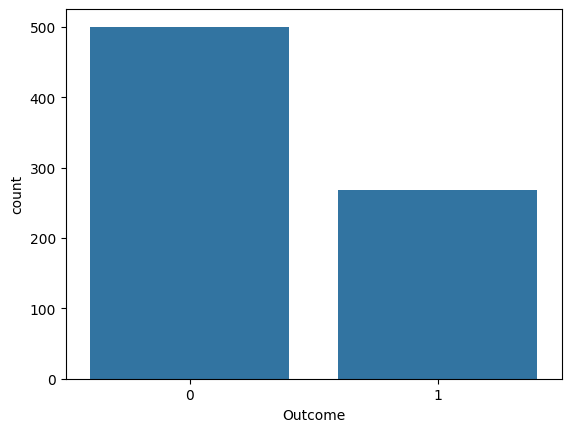

In [258]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(x="Outcome", data=df)
plt.show()

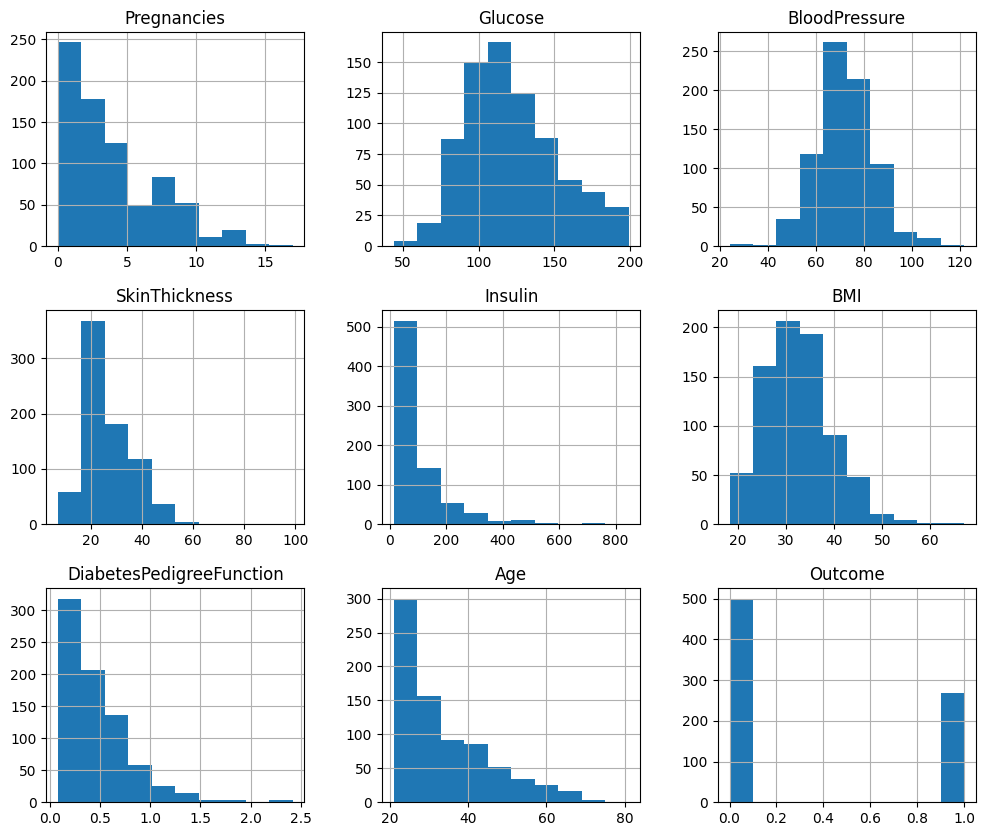

In [259]:
df.hist(figsize=(12,10))
plt.show()

In [260]:
# log transformation to reduce skewness
# df["Insulin"] = np.log1p(df["Insulin"])
# df["Insulin"].hist()

Pregnencies, insulin, DiabetesPedigreeFunction, Age are all left skewed

BoxPlot:

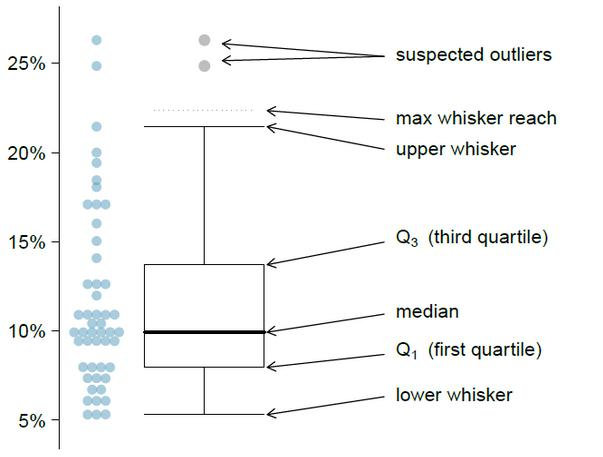
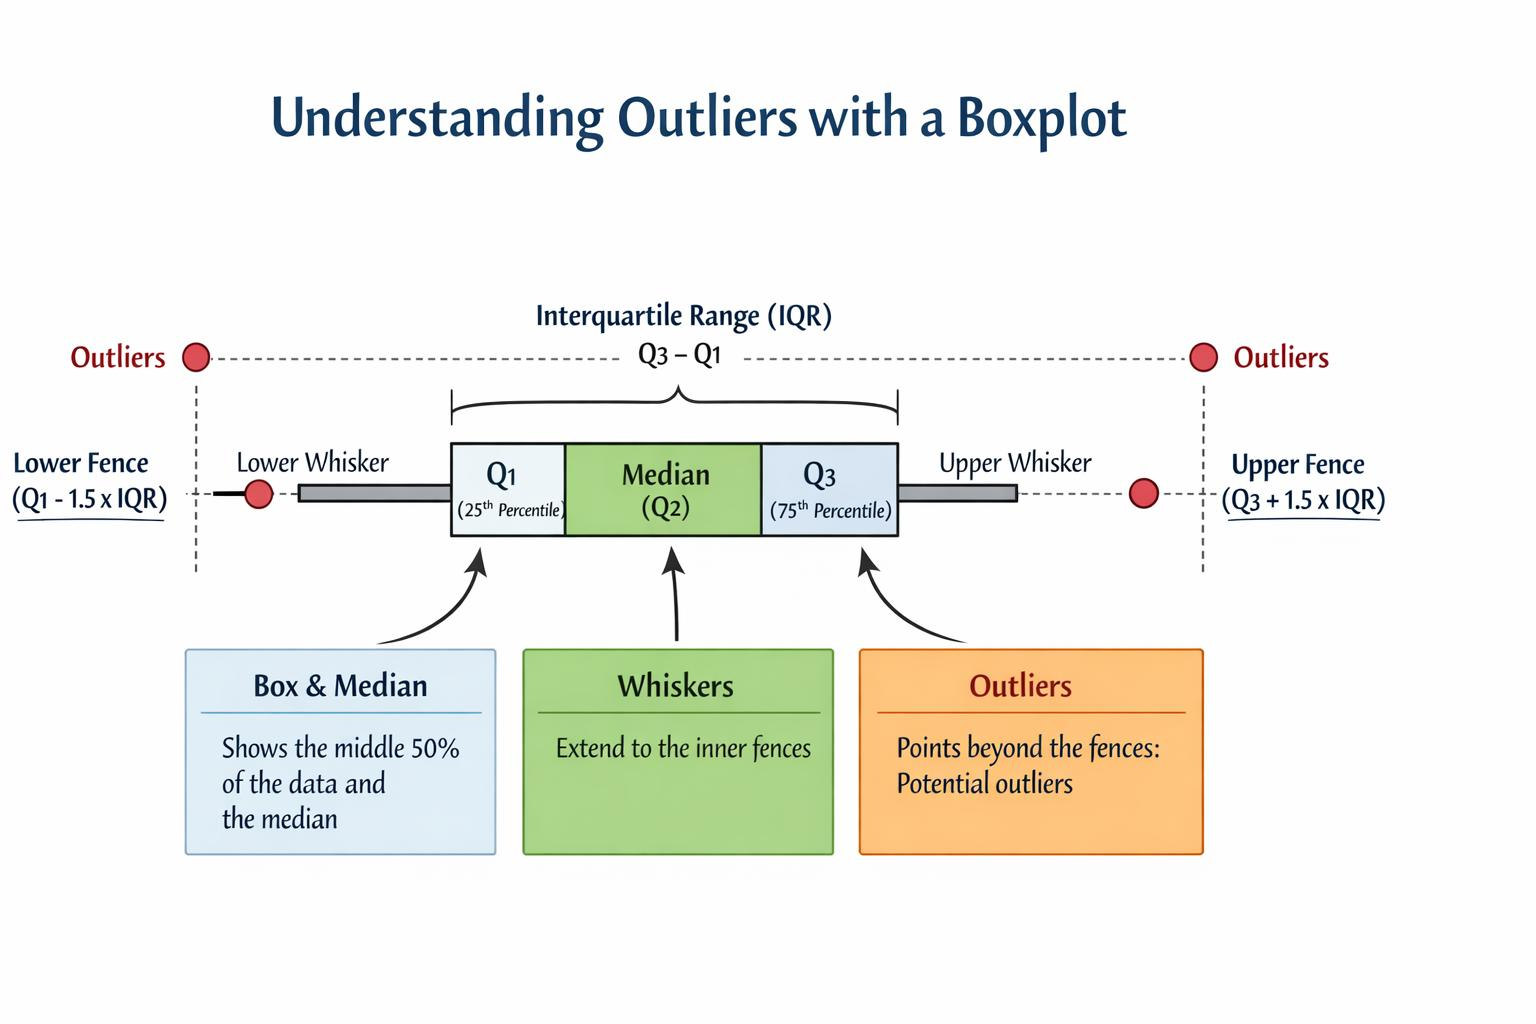

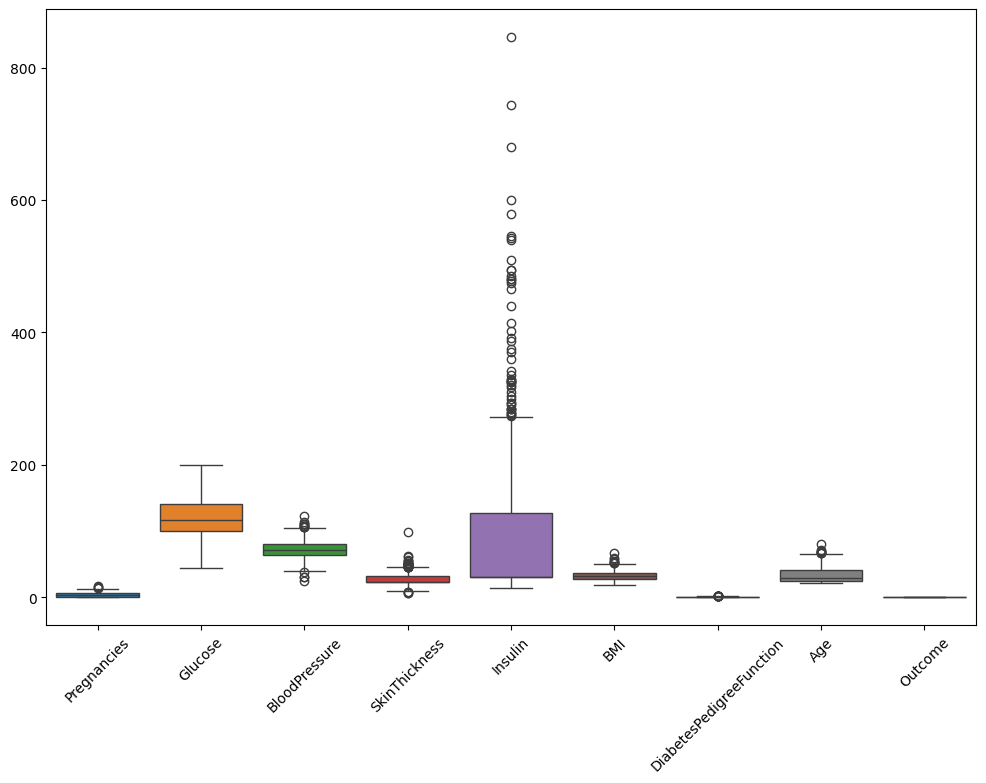

In [261]:
plt.figure(figsize=(12,8))
sns.boxplot(data=df)
plt.xticks(rotation=45)
plt.show()

most outliers are present in Insulin

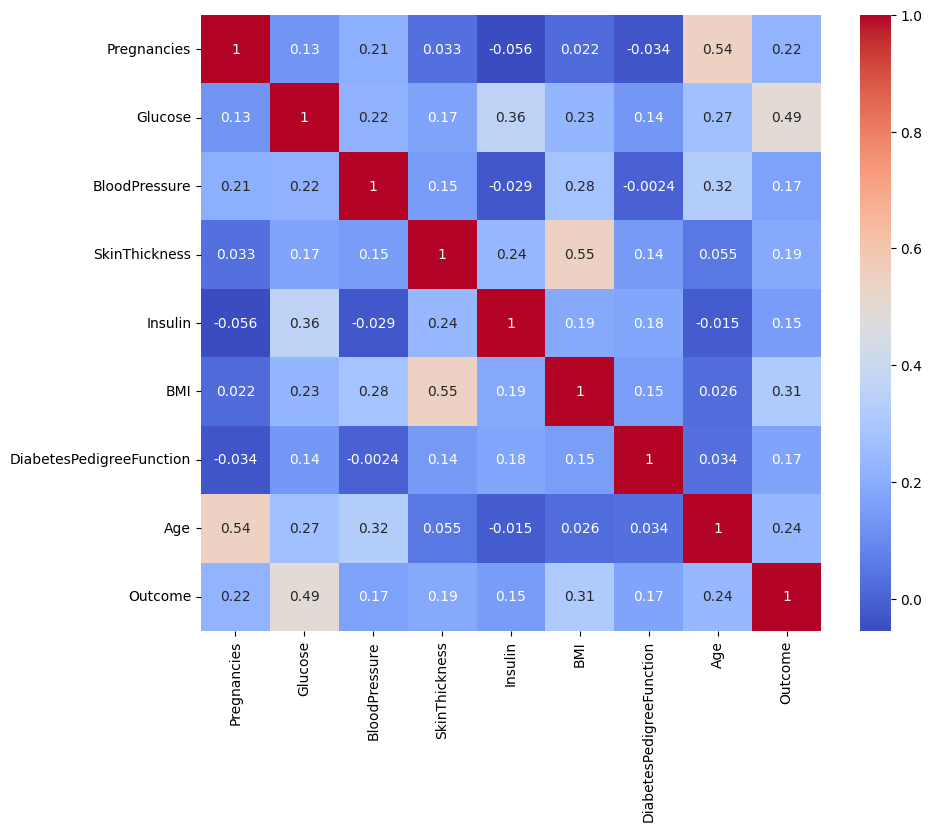

In [262]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,8))

sns.heatmap(
    df.corr(),
    annot=True,
    cmap="coolwarm"
)

plt.show()

Glucose has most correlation with outcome as it should be.

BMI is next most correlated with outcome

age and pregnacies rank third and fourth respectively

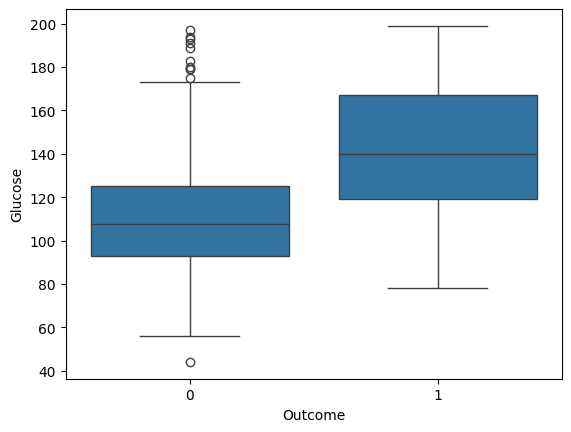

In [263]:
sns.boxplot(x="Outcome", y="Glucose", data=df)
plt.show()

by just comparing the median of both 0 and 1 outcome, higher glucose implies more chances of Diabetes (excluding outliers)

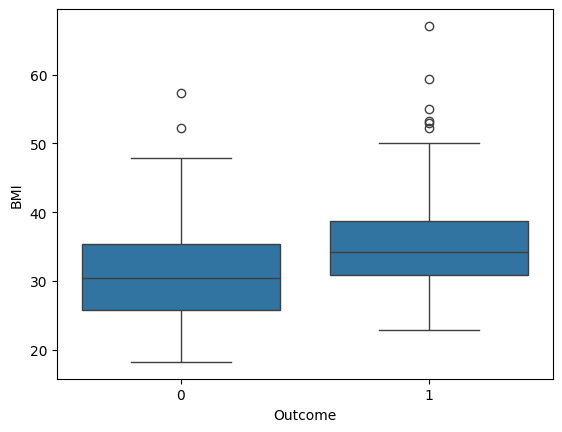

In [264]:
sns.boxplot(x="Outcome", y="BMI", data=df)
plt.show()

by just comparing the median of both 0 and 1 outcome, higher BMI implies more chances of Diabetes

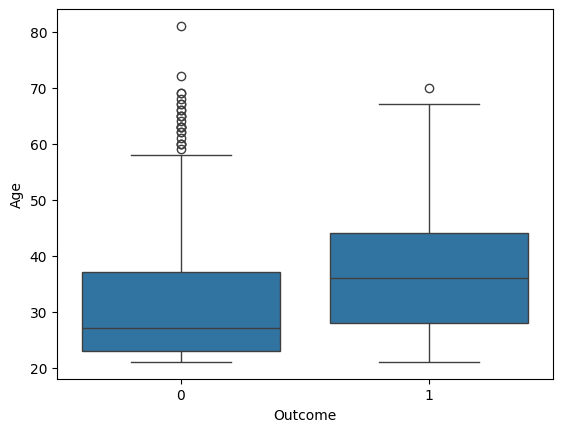

In [265]:
sns.boxplot(x="Outcome", y="Age", data=df)
plt.show()

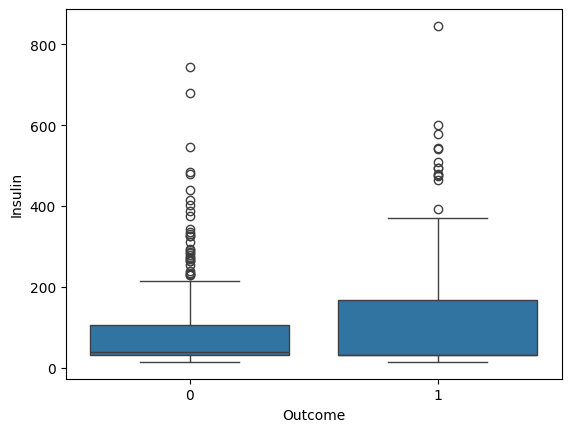

In [266]:
sns.boxplot(x="Outcome", y="Insulin", data=df)
plt.show()

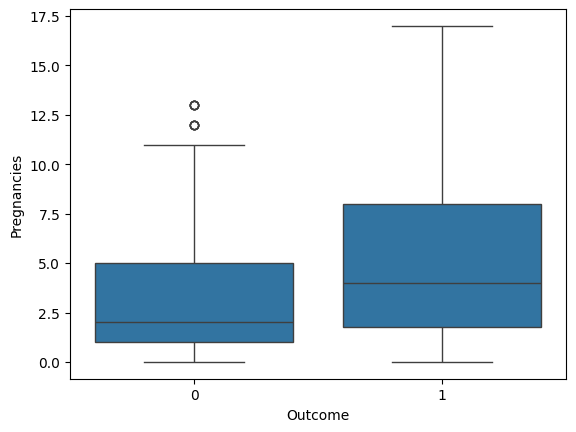

In [267]:
sns.boxplot(x="Outcome", y="Pregnancies", data=df)
plt.show()

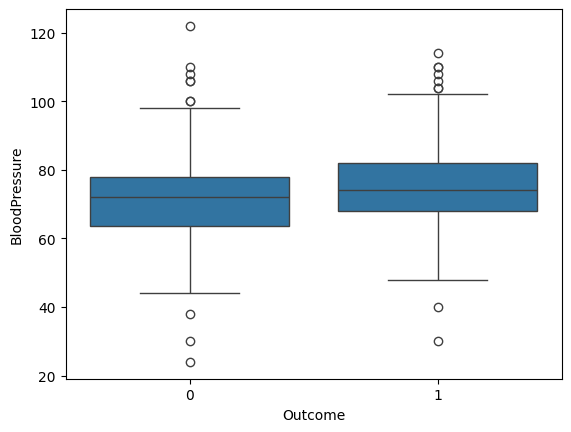

In [268]:
sns.boxplot(x="Outcome", y="BloodPressure", data=df)
plt.show()

no much difference in outcome if you have BP or not 

splitting data into input and output

In [269]:
X = df.drop("Outcome", axis=1)
y = df["Outcome"]

# cols=df.columns
# print(cols)

In [270]:
# feature scaling - normalization
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

In [271]:
np.random.seed(420)
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled,
    y,
    test_size=0.2,
    random_state=42
)

In [272]:
from sklearn.metrics import accuracy_score,f1_score, confusion_matrix,classification_report, precision_score,recall_score,roc_auc_score

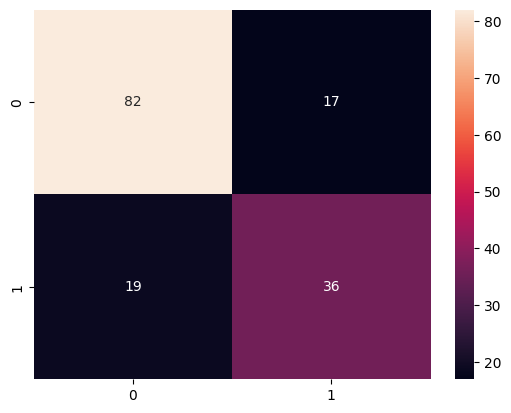

Accuracy: 0.7662337662337663
Precision: 0.6792452830188679
Recall: 0.6545454545454545
F1 Score: 0.6666666666666666
ROC-AUC  : 0.8196510560146923


In [273]:
# trying logistic regression:
from sklearn.linear_model import LogisticRegression

model=LogisticRegression()

model.fit(X_train,y_train)

y_pred=model.predict(X_test)
y_prob = model.predict_proba(X_test)[:,1]

cm = confusion_matrix(y_test, y_pred)

# print(cm)
sns.heatmap(cm, annot=True, fmt="d")
plt.show()

print("Accuracy:", accuracy_score(y_test, y_pred))

print("Precision:", precision_score(y_test, y_pred))

print("Recall:", recall_score(y_test, y_pred))

print("F1 Score:", f1_score(y_test, y_pred))

print("ROC-AUC  :", roc_auc_score(y_test, y_prob))



In [274]:
print("\nClassification Report:\n")

print(classification_report(y_test, y_pred))


Classification Report:

              precision    recall  f1-score   support

           0       0.81      0.83      0.82        99
           1       0.68      0.65      0.67        55

    accuracy                           0.77       154
   macro avg       0.75      0.74      0.74       154
weighted avg       0.76      0.77      0.77       154



In [275]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

In [276]:
results = {
    "Model": [],
    "Accuracy": [],
    "Precision": [],
    "Recall": [],
    "F1": [],
    "ROC-AUC": []
}

In [277]:
def evaluate_model(model, X_train, X_test, y_train, y_test):

    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)

    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)

    roc_auc = None

    if hasattr(model, "predict_proba"):
        y_prob = model.predict_proba(X_test)[:,1]
        roc_auc = roc_auc_score(y_test, y_prob)

    # Store results
    results["Model"].append(model.__class__.__name__)
    results["Accuracy"].append(accuracy)
    results["Precision"].append(precision)
    results["Recall"].append(recall)
    results["F1"].append(f1)
    results["ROC-AUC"].append(roc_auc)

In [278]:
# KNN classification
evaluate_model(KNeighborsClassifier(),X_train,X_test,y_train,y_test)

In [279]:
# Decision tree classification
evaluate_model(DecisionTreeClassifier(),X_train,X_test,y_train,y_test)

In [280]:
# SVM classification
evaluate_model(SVC(probability=True),X_train,X_test,y_train,y_test)

In [281]:
# Random forest Classification
evaluate_model(RandomForestClassifier(),X_train,X_test,y_train,y_test)

In [282]:
evaluate_model(LogisticRegression(),X_train,X_test,y_train,y_test)

In [283]:
# pip install xgboost

In [284]:
from xgboost import XGBClassifier

xgb_model = XGBClassifier(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=4,
    random_state=42
)

evaluate_model(
    xgb_model,
    X_train,
    X_test,
    y_train,
    y_test
)

Perceptron

In [285]:
from sklearn.linear_model import Perceptron

perceptron_model = Perceptron()

perceptron_model.fit(X_train, y_train)

y_pred = perceptron_model.predict(X_test)


print("Accuracy :", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall   :", recall_score(y_test, y_pred))
print("F1 Score :", f1_score(y_test, y_pred))
# perceptron model has no attribute predict_prob, hence we dont get y_prob in evaluate_model
 

Accuracy : 0.7077922077922078
Precision: 0.5694444444444444
Recall   : 0.7454545454545455
F1 Score : 0.6456692913385826


In [286]:
evaluate_model(Perceptron(),X_train,X_test,y_train,y_test)

Neural network

In [287]:
# neural network (multi-layer perceptron)
from sklearn.neural_network import MLPClassifier

mlp_model = MLPClassifier(
    hidden_layer_sizes=(32, 32, 32, 32), # 4 hidden layers with 32 neurons each
    max_iter=1000,
    random_state=42
)

evaluate_model(
    mlp_model,
    X_train,
    X_test,
    y_train,
    y_test
)

In [288]:
# converting results to dataframe
results_df = pd.DataFrame(results)

print(results_df)

                    Model  Accuracy  Precision    Recall        F1   ROC-AUC
0    KNeighborsClassifier  0.746753   0.642857  0.654545  0.648649  0.790634
1  DecisionTreeClassifier  0.714286   0.587302  0.672727  0.627119  0.705051
2                     SVC  0.753247   0.680851  0.581818  0.627451  0.808264
3  RandomForestClassifier  0.766234   0.672727  0.672727  0.672727  0.848577
4      LogisticRegression  0.766234   0.679245  0.654545  0.666667  0.819651
5           XGBClassifier  0.740260   0.627119  0.672727  0.649123  0.802938
6              Perceptron  0.707792   0.569444  0.745455  0.645669       NaN
7           MLPClassifier  0.694805   0.574074  0.563636  0.568807  0.719743


In [289]:
def plot_metric(metric):

    plt.figure(figsize=(10,6))

    ax = sns.barplot(
        x="Model",
        y=metric,
        data=results_df
    )

    for i in ax.containers:
        ax.bar_label(i, fmt="%.2f")

    plt.title(f"{metric} Comparison")

    plt.xticks(rotation=45)

    plt.ylim(0,1)

    plt.grid(axis='y', linestyle='--', alpha=0.5)

    plt.show()

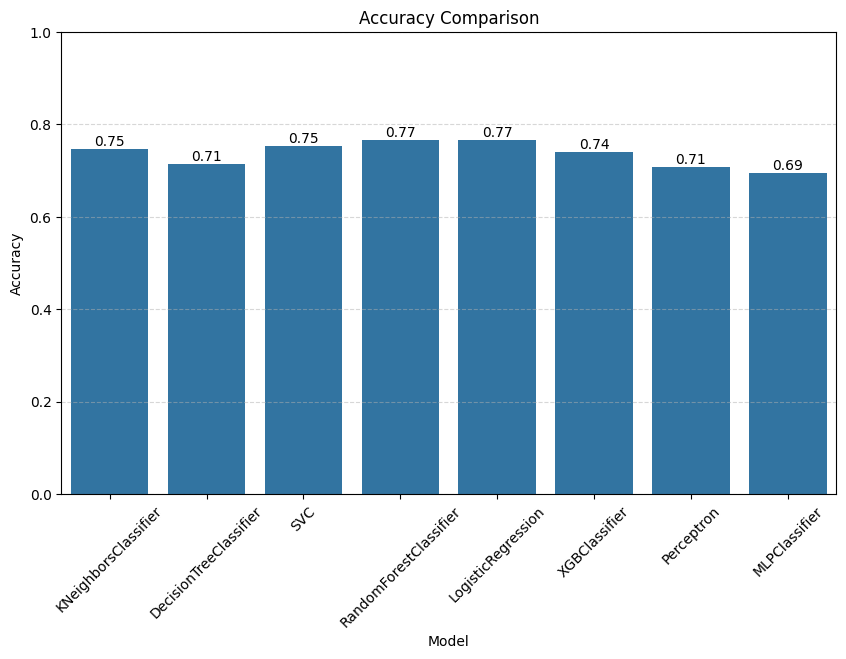

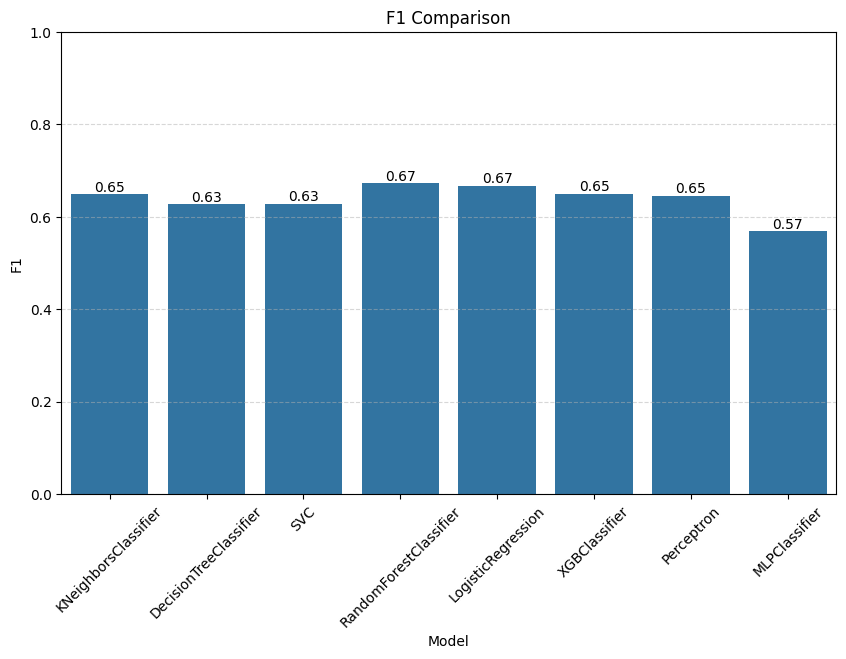

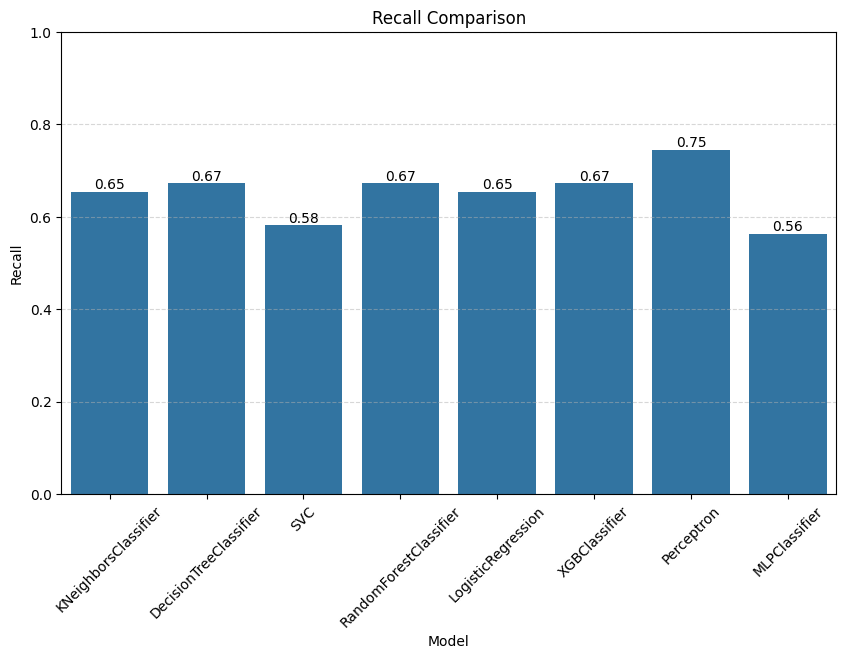

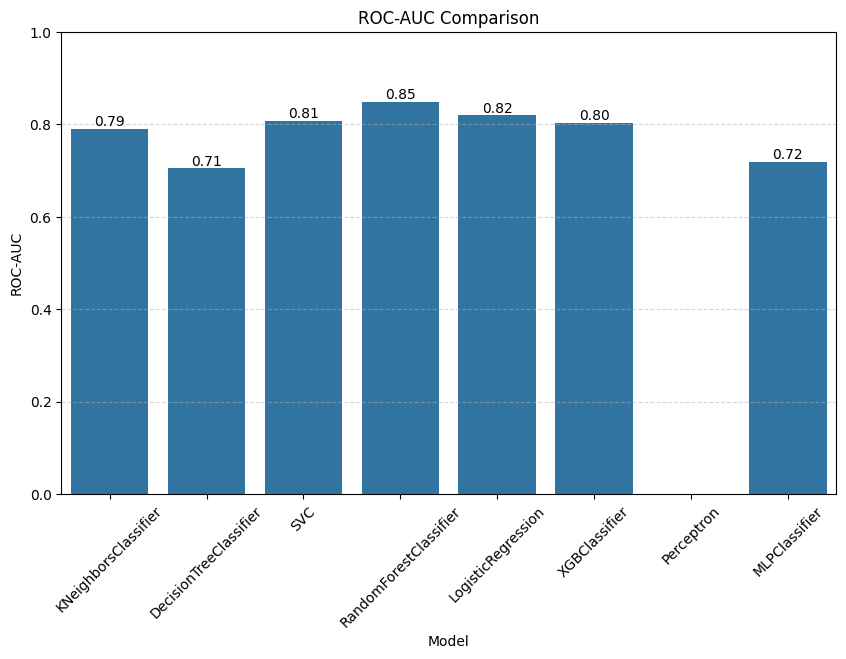

In [290]:
plot_metric("Accuracy")
plot_metric("F1")
plot_metric("Recall")
plot_metric("ROC-AUC")

from Above:

based on Accuracy, best model are Logistic Regression and random forest classifier

based on Recall, best model is Perceptron and then (decision tree,random forest classifier, Xgboost) 

based on f1-score, best model are Random forest classifier and Logistic Regression

based on ROC-AUC, best model is Random forest classifier and then comes Logistic Regression


## from above: we say random_forest is best model till now 

Random Forest achieved the best overall performance with the highest ROC-AUC (0.849), strongest F1-score (0.673), and competitive recall, making it the most reliable model for diabetes prediction in this study.

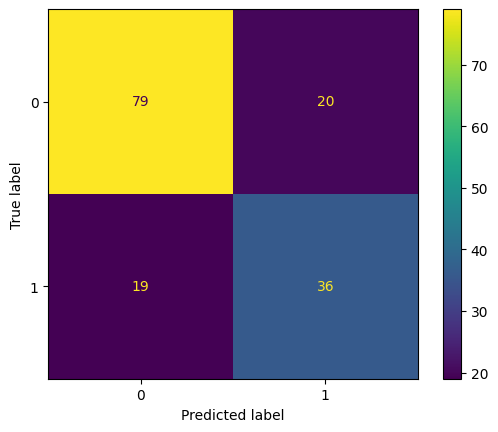

In [291]:
from sklearn.metrics import ConfusionMatrixDisplay

best_model=RandomForestClassifier()
best_model.fit(X_train, y_train)
ConfusionMatrixDisplay.from_estimator(best_model, X_test, y_test)
plt.show()

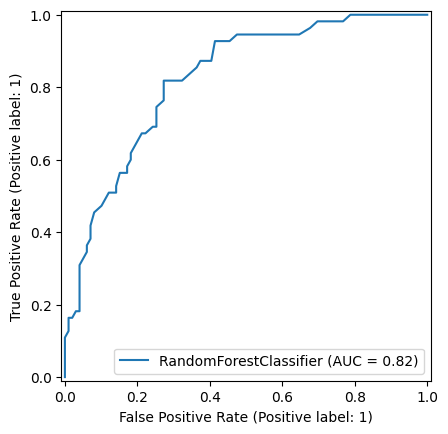

In [292]:
from sklearn.metrics import RocCurveDisplay

RocCurveDisplay.from_estimator(best_model, X_test, y_test)
plt.show()

<Axes: >

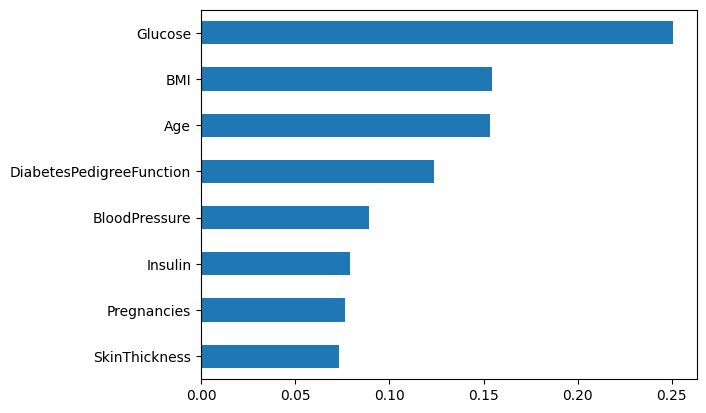

In [293]:
importance = best_model.feature_importances_

feat_imp = pd.Series(importance, index=X.columns)

feat_imp.sort_values().plot(kind='barh')

### hyperparamter tuning for random-forest

In [294]:
from sklearn.model_selection import GridSearchCV

rf = RandomForestClassifier(random_state=42)

In [295]:
param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [None, 5, 10, 20],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'criterion': ['gini', 'entropy']
}

# n_estimators is number of trees
# max_depth is tree depth
# min_samples_split is minimum samples to split
# min_samples_leaf is minimum samples in leaf node
# criterion is split quality measure

In [296]:
grid_search = GridSearchCV(
    estimator=rf,
    param_grid=param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1,
    verbose=2
)

# cv=5 is 5-fold cross validation
# scoring='accuracy' is optimize accuracy
# n_jobs=-1 is use all CPU cores
# verbose=2 is show training progress

In [297]:
# Train Grid Search
grid_search.fit(X_train, y_train)

print("Best Parameters:")
print(grid_search.best_params_)

Fitting 5 folds for each of 216 candidates, totalling 1080 fits
Best Parameters:
{'criterion': 'entropy', 'max_depth': 10, 'min_samples_leaf': 2, 'min_samples_split': 5, 'n_estimators': 200}


In [298]:
# best_model=RandomForestClassifier(criterion='entropy',max_depth=10,min_samples_leaf=2,min_samples_split=5,n_estimators=200)

best_model = RandomForestClassifier(
    criterion='entropy',
    max_depth=10,
    min_samples_leaf=2,
    min_samples_split=5,
    n_estimators=200,
    random_state=42
)

best_model.fit(X_train,y_train)
y_pred=best_model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))

print("Precision:", precision_score(y_test, y_pred))

print("Recall:", recall_score(y_test, y_pred))

print("F1 Score:", f1_score(y_test, y_pred))

print("ROC-AUC  :", roc_auc_score(y_test, y_prob))


Accuracy: 0.7662337662337663
Precision: 0.6666666666666666
Recall: 0.6909090909090909
F1 Score: 0.6785714285714286
ROC-AUC  : 0.8196510560146923


not much change in result after hyper-parameter tuning

# PCA Analysis

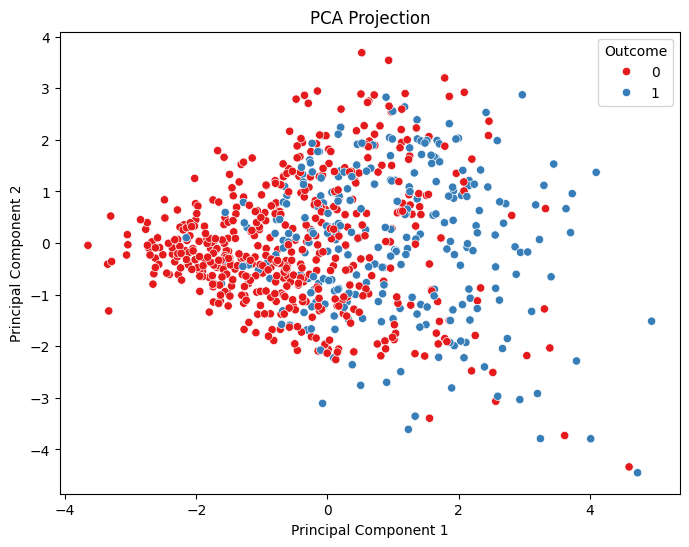

In [299]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)

X_pca = pca.fit_transform(X_scaled)

plt.figure(figsize=(8,6))

sns.scatterplot(
    x=X_pca[:,0],
    y=X_pca[:,1],
    hue=y,
    palette="Set1"
)

plt.title("PCA Projection")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")

plt.show()



projecting points onto PC-1 and PC-2 does not linerly separate the 2 classes (i.e the outcomes)

In [300]:
print(pca.explained_variance_ratio_)

[0.27429654 0.20541242]


PC-1 only covers 26% and PC-2 covers only 21% importance, hence its not so helpful to do PCA analysis in 2D

# LDA Analysis

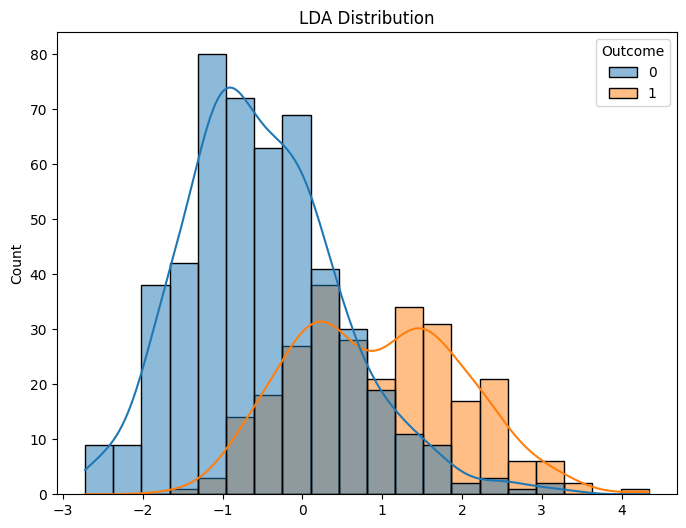

In [301]:
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
#  as number of unique outcomes (0 and 1) is 2,
# and no: of input features= 8 
# hence no of lda components=  min(8,2-1=1) =1  

lda = LinearDiscriminantAnalysis(n_components=1)

X_lda = lda.fit_transform(X_scaled, y)

plt.figure(figsize=(8,6))

sns.histplot(
    x=X_lda[:,0],
    hue=y,
    kde=True
)

plt.title("LDA Distribution")

plt.show()

(614, 1)


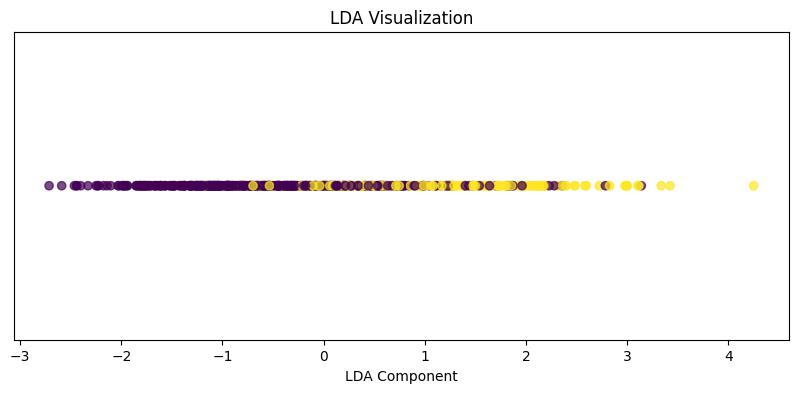

In [303]:
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis

# ======================================
# LDA
# ======================================

lda = LinearDiscriminantAnalysis(
    n_components=1
)
X_train_scaled= scaler.fit_transform(X_train)
X_lda = lda.fit_transform(
    X_train_scaled,
    y_train
)

print(X_lda.shape)


plt.figure(figsize=(10,4))

plt.scatter(

    X_lda,

    [0] * len(X_lda),

    c=y_train,

    alpha=0.7
)

plt.title("LDA Visualization")

plt.yticks([])

plt.xlabel("LDA Component")

plt.show()

from above we see that lda does not give linearly separable classes, also the variance is low for each class, and the varaince btw 2 classes is also low, hence not much useful here